# Initial Implementation of MALA
The discretisation of the overdamped Langevin SDE (the one quoted by Randolf) leads to the unadjested Langevin Algorithm, which converges to the stationary dist'n but with an error of epsilon.

To kill this bias, we implement MALA, which treats the step as a proposal and adds a Metropolis-Hastings accept/reject correction (see Duncan 2016).

In [53]:
"""Sampler Implementation."""

import numpy as np

def mala(log_prob, grad_log_prob, x0, step_size, n_samples, rng=None):
    """Metropolis-Adjusted Langevin Algorithm.

    log_prob, grad_log_prob: callables x -> scalar / x -> array, on the
        UNnormalised log target.
    Returns (samples, acceptance_rate).
    """
    rng = rng or np.random.default_rng()
    x = np.asarray(x0, dtype=float)
    d = x.shape[0]
    samples = np.empty((n_samples, d))
    n_accept = 0

    lp_x = log_prob(x)
    g_x = grad_log_prob(x)

    for k in range(n_samples):
        mean_x = x + step_size * g_x                       # proposal mean from x
        y = mean_x + np.sqrt(2 * step_size) * rng.standard_normal(d)

        lp_y = log_prob(y)
        g_y = grad_log_prob(y)
        mean_y = y + step_size * g_y                        # proposal mean from y

        # log proposal densities (shared 1/(4πε)^{d/2} constant cancels)
        log_q_y_given_x = -np.sum((y - mean_x) ** 2) / (4 * step_size)
        log_q_x_given_y = -np.sum((x - mean_y) ** 2) / (4 * step_size)

        log_alpha = (lp_y - lp_x) + (log_q_x_given_y - log_q_y_given_x)

        if np.log(rng.random()) < log_alpha:
            x, lp_x, g_x = y, lp_y, g_y
            n_accept += 1
        samples[k] = x

    return samples, n_accept / n_samples

We now test this against a known target dist'n; strongly correlated 2D Gaussian, the case that trips up random-walk Metropolis, to show that it works.

In [54]:
Sigma = np.array([[1.0, 0.9], [0.9, 1.0]])
Sigma_inv = np.linalg.inv(Sigma)

def log_prob(x):       return -0.5 * x @ Sigma_inv @ x
def grad_log_prob(x):  return -Sigma_inv @ x

Run, discard, check moments:

In [55]:
rng = np.random.default_rng(0)
samples, acc = mala(log_prob, grad_log_prob, x0=np.zeros(2),
                    step_size=0.25, n_samples=20_000, rng=rng)

burn = 2_000
s = samples[burn:]
print(f"acceptance rate: {acc:.3f}")
print("sample mean:", s.mean(0))                  # ~ [0, 0]
print("sample cov:\n", np.cov(s.T))               # ~ Sigma

acceptance rate: 0.393
sample mean: [-0.00347193 -0.0027236 ]
sample cov:
 [[0.98802712 0.88747515]
 [0.88747515 0.98160908]]


Diagnostic plots:

NEW: we define the autocorrelation function and, built on top of it, per Randolf's recommendation, we define the ESS function. This represents rougly the number of independent draws the correlated chain is worth. ESS is going to be our mixing diagnostic in what follows: it summarises the whole autocorrelation curve through the integrated autocorrelation time, instead of relying on a single lag. We define these helpers with the benefit of being able to call them in below comparisons.

Also of note is that we now use the FFT to compute the autocorrelation. The reasoning here is that the O(nlogn) advantage over the previous (commented out) O(n^2) implementation. This matters now as ESS does a full-lag autocorrelation per coordinate on chains of 10k-25k+ rather than just reading the unit lag -- the improvement becomes noticeable.

In [56]:
# import matplotlib.pyplot as plt

# def autocorr(x, max_lag=200):
#     x = x - x.mean()
#     ac = np.correlate(x, x, "full")[len(x)-1:]
#     return (ac / ac[0])[:max_lag]

# fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
# ax[0].plot(s[:1000, 0], lw=0.6); ax[0].set_title("trace, coord 0")
# ax[1].plot(autocorr(s[:, 0]));   ax[1].set_title("autocorrelation, coord 0")
# plt.tight_layout()

import matplotlib.pyplot as plt


def autocorr(x, max_lag=200):
    """Normalised autocorrelation function via FFT (O(n log n)).

    Returns rho_0, rho_1, ... rho_{max_lag-1} with rho_0 = 1. Using the FFT
    (rather than np.correlate, which is O(n^2)) keeps the full-lag computation
    needed for ESS cheap on long chains.
    """
    x = np.asarray(x, dtype=float)
    x = x - x.mean()
    n = x.size
    if max_lag is None:
        max_lag = n
    m = 1 << (2 * n - 1).bit_length()          # zero-pad to avoid wrap-around
    f = np.fft.rfft(x, m)
    ac = np.fft.irfft(f * np.conjugate(f), m)[:n].real
    return (ac / ac[0])[:max_lag]


def integrated_autocorr_time(x, max_lag=None):
    """Initial-positive-sequence (Geyer) estimate of the integrated
    autocorrelation time tau = 1 + 2 sum_k rho_k.
    """
    x = np.asarray(x, dtype=float)
    if max_lag is None:
        max_lag = min(1000, x.size)

    # Autocorrelation values rho_k measure dependence between samples k steps apart.
    acorr = np.asarray(autocorr(x, max_lag=max_lag), dtype=float)
    if acorr.size < 3:
        return 1.0

    # tau = 1 + 2 sum rho_k inflates Monte Carlo variance due to dependence.
    tau = 1.0
    for k in range(1, acorr.size - 1, 2):
        pair_sum = acorr[k] + acorr[k + 1]
        if pair_sum <= 0:                       # truncate once paired sum turns negative
            break
        tau += 2.0 * pair_sum
    return max(float(tau), 1.0)


def effective_sample_size(x, max_lag=None):
    """Effective sample size ESS = N / tau for a one-dimensional chain."""
    x = np.asarray(x, dtype=float)
    tau = integrated_autocorr_time(x, max_lag=max_lag)
    return min(float(x.size), float(x.size / tau))


def min_coordinate_ess(samples, max_lag=None):
    """Conservative ESS: the worst-mixing coordinate of a multi-d chain."""
    samples = np.asarray(samples, dtype=float)
    return min(effective_sample_size(samples[:, j], max_lag=max_lag)
               for j in range(samples.shape[1]))

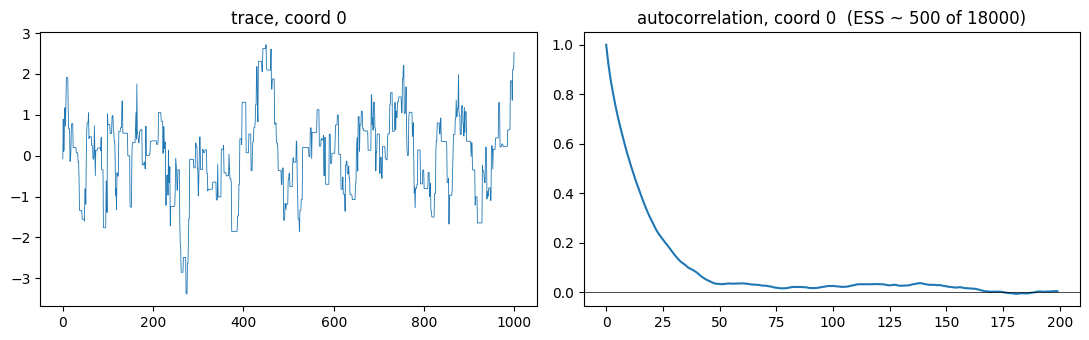

In [57]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
ax[0].plot(s[:1000, 0], lw=0.6)
ax[0].set_title("trace, coord 0")

ac = autocorr(s[:, 0])
ess = effective_sample_size(s[:, 0])
ax[1].plot(ac)
ax[1].axhline(0.0, color="k", lw=0.5)
ax[1].set_title(f"autocorrelation, coord 0  (ESS ~ {ess:.0f} of {len(s)})")
plt.tight_layout()
plt.show()

We can now tune the step-size. NB: too small and we get high acceptance and autocorrelation; too large and proposals for target dist'ns get rejected easily.

**Unadjusted Langevin Algorithm implementation**

In [58]:
def ula(grad_log_prob, x0, step_size, n_samples, rng=None):
    """Unadjusted Langevin Algorithm / Langevin Monte Carlo.
    """
    rng = rng or np.random.default_rng()
    x = np.asarray(x0, dtype=float).copy()
    d = x.shape[0]
    samples = np.empty((n_samples, d))

    noise_scale = np.sqrt(2 * step_size)

    for k in range(n_samples):
        x = x + step_size * grad_log_prob(x) + noise_scale * rng.standard_normal(d)
        samples[k] = x

    return samples


In [59]:
rng = np.random.default_rng(0)
ula_samples = ula(grad_log_prob, x0=np.zeros(2),
                  step_size=0.05, n_samples=20_000, rng=rng)

burn = 2_000
u = ula_samples[burn:]
print("ULA sample mean:", u.mean(0))
print("ULA sample cov:\n", np.cov(u.T))

ULA sample mean: [0.05395622 0.04801748]
ULA sample cov:
 [[1.11413301 0.9718062 ]
 [0.9718062  1.09895202]]


Comparing:


*   Mean Error
*   covariance error
*   min effective sample size (ESS) -- a standard summary of how fast autocorrelation decays (NEW: now implemented below)



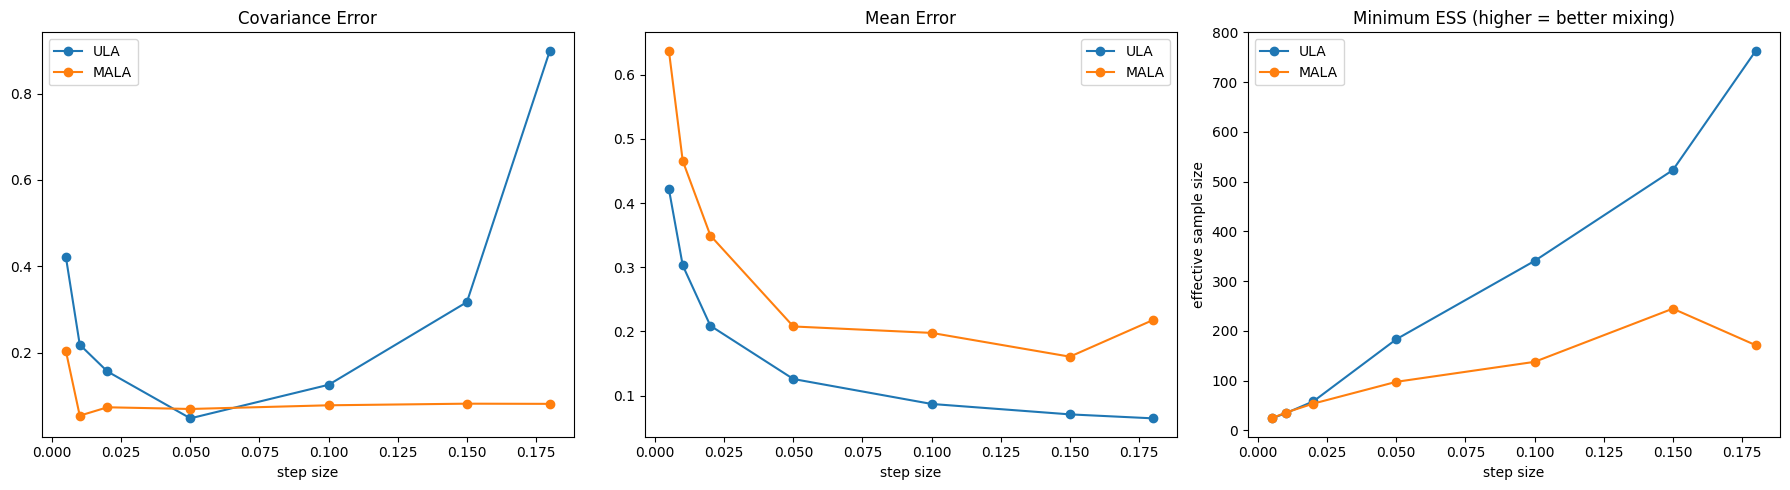

In [60]:
def gaussian_errors(samples, true_mean, true_cov):
    sample_mean = samples.mean(axis=0)
    sample_cov = np.cov(samples.T)
    return {
        "mean_error": np.linalg.norm(sample_mean - true_mean),
        "cov_error": np.linalg.norm(sample_cov - true_cov, ord="fro"),
    }

true_mean = np.zeros(2)
true_cov = Sigma
step_grid = [0.005, 0.01, 0.02, 0.05, 0.10, 0.15, 0.18]
n_samples_cmp = 12_000
burn_cmp = 2_000
rows = []

# Redefine log_prob and grad_log_prob for the 2D Gaussian specifically for this block
def log_prob(x):       return -0.5 * x @ Sigma_inv @ x
def grad_log_prob(x):  return -Sigma_inv @ x

for h in step_grid:
    rng_ula = np.random.default_rng(0)
    us = ula(grad_log_prob, np.zeros(2), h, n_samples_cmp, rng=rng_ula)[burn_cmp:]
    u_err = gaussian_errors(us, true_mean, true_cov)
    u_ess = min_coordinate_ess(us)

    rng_mala = np.random.default_rng(0)
    ms, m_acc = mala(log_prob, grad_log_prob, np.zeros(2), h, n_samples_cmp, rng=rng_mala)
    ms = ms[burn_cmp:]
    m_err = gaussian_errors(ms, true_mean, true_cov)
    m_ess = min_coordinate_ess(ms)

    rows.append({
        "h": h,
        "ula_mean_error": u_err["mean_error"],
        "ula_cov_error": u_err["cov_error"],
        "ula_ess": u_ess,
        "mala_mean_error": m_err["mean_error"],
        "mala_cov_error": m_err["cov_error"],
        "mala_ess": m_ess,
        "mala_acceptance": m_acc,
    })

hs = np.array([r["h"] for r in rows])
ula_cov = np.array([r["ula_cov_error"] for r in rows])
mala_cov = np.array([r["mala_cov_error"] for r in rows])
ula_mean = np.array([r["ula_mean_error"] for r in rows])
mala_mean = np.array([r["mala_mean_error"] for r in rows])
ula_ess = np.array([r["ula_ess"] for r in rows])
mala_ess = np.array([r["mala_ess"] for r in rows])

fig, ax = plt.subplots(1, 3, figsize=(18, 5))

# Covariance Error Plot
ax[0].plot(hs, ula_cov, marker="o", label="ULA")
ax[0].plot(hs, mala_cov, marker="o", label="MALA")
ax[0].set_title("Covariance Error")
ax[0].set_xlabel("step size")
ax[0].legend()

# Mean Error Plot
ax[1].plot(hs, ula_mean, marker="o", label="ULA")
ax[1].plot(hs, mala_mean, marker="o", label="MALA")
ax[1].set_title("Mean Error")
ax[1].set_xlabel("step size")
ax[1].legend()

# ESS Plot
ax[2].plot(hs, ula_ess, marker="o", label="ULA")
ax[2].plot(hs, mala_ess, marker="o", label="MALA")
ax[2].set_title("Minimum ESS (higher = better mixing)")
ax[2].set_xlabel("step size")
ax[2].set_ylabel("effective sample size")
ax[2].legend()

plt.tight_layout()
plt.show()

Minimum ESS (right) is as expected. ULA never rejects, so it keeps moving and its ESS climbs monotonically (24 → 763). MALA's acceptance falls from 0.997 down to 0.545 as h grows, and rejections produce repeated states, so its ESS peaks (approx 245 at h=0.15) and then turns over (approx 171 at h=0.18). ULA sitting well above MALA is the normal price MALA pays for the correction.

Don't read the mean and ESS panels on their own. At h=0.18 ULA has the lowest mean error and roughly 4× MALA's ESS — yet its covariance error is ~0.9 versus MALA's ~0.08. That's ULA efficiently sampling the *wrong* distribution. The zero-centred target makes the mean trivial to hit; the bias only surfaces in the spread, which is precisely the covariance panel. So the three together tell the correct story — ESS and mean alone would flatter ULA, and the covariance panel is what keeps you honest. That's the point of showing all three.

# Performance for linear regression
With linear regression, we gain a point estimate for the MLE of the fitted coefficients. However, using Bayesian linear regression instead, we hold information as to the distribution of the betas as well, giving us their posterior - the likelihood of each set of coefficients given the data.

Linear regression is a good example to concretely test against because the linear regression distribution over the betas is Gaussian, with a mean and width determined by X and Y.

In [61]:
def make_linear_regression(n=200, d=5, sigma=1.0, tau=10.0, seed=0):
    """Bayesian linear regression: y = X beta + N(0, sigma^2), prior N(0, tau^2 I).
    Posterior is Gaussian -> exact (mean, cov) returned for scoring."""
    rng = np.random.default_rng(seed)
    X = rng.standard_normal((n, d))
    beta_true = rng.standard_normal(d)
    y = X @ beta_true + sigma * rng.standard_normal(n)

    A = X.T @ X / sigma**2 + np.eye(d) / tau**2     # posterior precision
    post_cov = np.linalg.inv(A)
    post_mean = post_cov @ (X.T @ y) / sigma**2

    def log_prob(beta):
        r = y - X @ beta
        return -0.5 * r @ r / sigma**2 - 0.5 * beta @ beta / tau**2
        # NB: the first term represents the likelihood given the data, the second
        # term ensures the betas stay close to zero (a "plausibility" score)

    def grad_log_prob(beta):
        return X.T @ (y - X @ beta) / sigma**2 - beta / tau**2

    return log_prob, grad_log_prob, post_mean, post_cov

lin_log_prob, lin_grad, post_mean, post_cov = make_linear_regression()
d = post_mean.shape[0]

step_grid = [0.0005, 0.001, 0.002, 0.003, 0.005, 0.007]
n_samples_cmp, burn_cmp = 20_000, 4_000
lin_rows = []

for h in step_grid:
    us = ula(lin_grad, np.zeros(d), h, n_samples_cmp,
             rng=np.random.default_rng(0))[burn_cmp:]
    u_err = gaussian_errors(us, post_mean, post_cov)
    u_ess = min_coordinate_ess(us)

    ms, m_acc = mala(lin_log_prob, lin_grad, np.zeros(d), h, n_samples_cmp,
                     rng=np.random.default_rng(0))
    ms = ms[burn_cmp:]
    m_err = gaussian_errors(ms, post_mean, post_cov)
    m_ess = min_coordinate_ess(ms)

    lin_rows.append(dict(h=h,
                         ula_mean=u_err["mean_error"], ula_cov=u_err["cov_error"], ula_ess=u_ess,
                         mala_mean=m_err["mean_error"], mala_cov=m_err["cov_error"], mala_ess=m_ess,
                         mala_acc=m_acc))

    print(f"h={h:.4f}  MALA acc={m_acc:.3f}")

h=0.0005  MALA acc=0.981
h=0.0010  MALA acc=0.948
h=0.0020  MALA acc=0.855
h=0.0030  MALA acc=0.732
h=0.0050  MALA acc=0.473
h=0.0070  MALA acc=0.261


**Can drop existing two-panel plotting block straight onto rows (the keys are shorter here — ula_cov, mala_cov, etc.)**

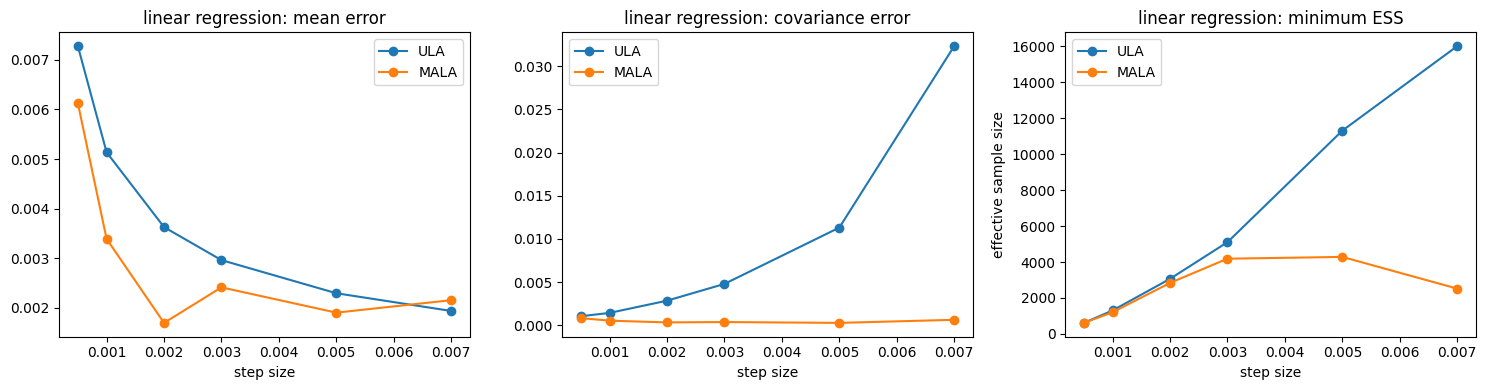

In [62]:
hs = np.array([r["h"] for r in lin_rows])

ula_mean = np.array([r["ula_mean"] for r in lin_rows])
mala_mean = np.array([r["mala_mean"] for r in lin_rows])
ula_cov = np.array([r["ula_cov"] for r in lin_rows])
mala_cov = np.array([r["mala_cov"] for r in lin_rows])
ula_ess = np.array([r["ula_ess"] for r in lin_rows])
mala_ess = np.array([r["mala_ess"] for r in lin_rows])
mala_acc = np.array([r["mala_acc"] for r in lin_rows])

fig, ax = plt.subplots(1, 3, figsize=(15, 4))

ax[0].plot(hs, ula_mean, marker="o", label="ULA")
ax[0].plot(hs, mala_mean, marker="o", label="MALA")
ax[0].set_title("linear regression: mean error")
ax[0].set_xlabel("step size")
ax[0].legend()

ax[1].plot(hs, ula_cov, marker="o", label="ULA")
ax[1].plot(hs, mala_cov, marker="o", label="MALA")
ax[1].set_title("linear regression: covariance error")
ax[1].set_xlabel("step size")
ax[1].legend()

ax[2].plot(hs, ula_ess, marker="o", label="ULA")
ax[2].plot(hs, mala_ess, marker="o", label="MALA")
ax[2].set_title("linear regression: minimum ESS")
ax[2].set_xlabel("step size")
ax[2].set_ylabel("effective sample size")
ax[2].legend()

plt.tight_layout()
plt.show()

What we see above mirrors the Gaussian case: ULA's covariance flattens out or worsens with epsilon because its stationary dist'n is always O(epsilon) from the true posterior. On the other hand, MALA's distance from the posterior is limited only by Monte Carlo noise.

With logistic regression the posterior is no longer Gaussian and we have no ground truth, however the log posterior and its gradient not hard to find.

In [63]:
from scipy.special import expit

def make_logistic_regression(n=400, d=5, tau=10.0, seed=0):
    """Bayesian logistic regression, prior N(0, tau^2 I). Posterior is non-Gaussian."""
    rng = np.random.default_rng(seed)
    X = rng.standard_normal((n, d))
    beta_true = rng.standard_normal(d)
    y = (rng.random(n) < expit(X @ beta_true)).astype(float)

    def log_prob(beta):
        z = X @ beta
        ll = np.sum(y * z - np.logaddexp(0.0, z))    # sum y*z - log(1+e^z)
        return ll - 0.5 * beta @ beta / tau**2

    def grad_log_prob(beta):
        return X.T @ (y - expit(X @ beta)) - beta / tau**2
        # use expit for numerical stability of sigmoids

    return log_prob, grad_log_prob, X, y, tau

The ground truth is a long small-step MALA chain. We instead choose to also use the laplacian approximation, which is a Gaussian at the MAP with covariance equal to the inverse Hessian of the negative log posterior. Comparing the two will also show how non-Gaussian the posterior really is.

In [64]:
from scipy.optimize import minimize

def laplace(log_prob, grad_log_prob, X, y, tau):
    d = X.shape[1]
    res = minimize(lambda b: -log_prob(b), np.zeros(d),
                   jac=lambda b: -grad_log_prob(b), method="L-BFGS-B")
    beta_map = res.x
    s = expit(X @ beta_map)
    H = X.T @ ((s * (1 - s))[:, None] * X) + np.eye(d) / tau**2   # neg-log-post Hessian
    return beta_map, np.linalg.inv(H)

log_prob, grad, X, y, tau = make_logistic_regression()
d = X.shape[1]
beta_map, lap_cov = laplace(log_prob, grad, X, y, tau)

# empirical gold standard: long, conservative MALA run
ref, ref_acc = mala(log_prob, grad, beta_map, step_size=0.004,
                    n_samples=80_000, rng=np.random.default_rng(123))
ref = ref[10_000:]
ref_mean, ref_cov = ref.mean(0), np.cov(ref.T)
print(f"reference MALA acc={ref_acc:.3f}")
print("Laplace vs MALA mean diff:", np.linalg.norm(beta_map - ref_mean))

reference MALA acc=0.957
Laplace vs MALA mean diff: 0.06920101791051377


We use the Hessian to determine the relative steepness of our landscape and use this in turn to determine a sensible step size so as to continuously step in the steepest direction (where the largest eigenvalue is of the Hessian) and not overshoot our gradient descent.

We nudge the step size until the MALA acceptance criterion is at around 0.574 (as per the optimal acceptance rate). We are also using the same sweep, scoring against reference values with gaussian errors as there is no concrete comparison to be made with logistic regression. We get these reference values by running a long MALA chain and treating its mean and covariance as the truth.

Now we do the same ULA/MALA comparison for logistic regression. Since the true posterior is not available in closed form, I score both samplers against the long MALA reference chain above, and report ESS as the mixing diagnostic.

This is not perfect ground truth, but it gives us a practical benchmark for checking whether the shorter chains are close to a conservative reference run.

In [65]:
log_step_grid = [0.001, 0.002, 0.004, 0.006, 0.008, 0.010, 0.015, 0.020]
n_samples_cmp, burn_cmp = 30_000, 5_000
log_rows = []

for h in log_step_grid:
    us = ula(grad, beta_map, h, n_samples_cmp,
             rng=np.random.default_rng(0))[burn_cmp:]
    u_err = gaussian_errors(us, ref_mean, ref_cov)
    u_ess = min_coordinate_ess(us)

    ms, m_acc = mala(log_prob, grad, beta_map, h, n_samples_cmp,
                     rng=np.random.default_rng(0))
    ms = ms[burn_cmp:]
    m_err = gaussian_errors(ms, ref_mean, ref_cov)
    m_ess = min_coordinate_ess(ms)

    log_rows.append(dict(h=h,
                         ula_mean=u_err["mean_error"], ula_cov=u_err["cov_error"], ula_ess=u_ess,
                         mala_mean=m_err["mean_error"], mala_cov=m_err["cov_error"], mala_ess=m_ess,
                         mala_acc=m_acc))

print(f"{'h':>8} | {'ULA mean':>9} {'ULA cov':>9} {'ULA ESS':>8} | {'MALA mean':>9} {'MALA cov':>9} {'MALA ESS':>9} {'acc':>7}")
print("-" * 92)
for r in log_rows:
    print(f"{r['h']:8.4f} | {r['ula_mean']:9.3f} {r['ula_cov']:9.3f} {r['ula_ess']:8.1f} | "
          f"{r['mala_mean']:9.3f} {r['mala_cov']:9.3f} {r['mala_ess']:9.1f} {r['mala_acc']:7.3f}")

       h |  ULA mean   ULA cov  ULA ESS | MALA mean  MALA cov  MALA ESS     acc
--------------------------------------------------------------------------------------------
  0.0010 |     0.026     0.011    211.1 |     0.037     0.007     144.9   0.995
  0.0020 |     0.023     0.007    374.9 |     0.023     0.005     342.3   0.986
  0.0040 |     0.022     0.006    777.8 |     0.019     0.004     627.1   0.957
  0.0060 |     0.023     0.009   1193.4 |     0.017     0.003     955.1   0.922
  0.0080 |     0.026     0.013   1573.0 |     0.015     0.003    1227.9   0.883
  0.0100 |     0.028     0.016   1939.5 |     0.012     0.003    1528.0   0.837
  0.0150 |     0.038     0.026   2890.3 |     0.011     0.004    1868.6   0.702
  0.0200 |     0.051     0.041   4029.5 |     0.009     0.005    2117.5   0.559


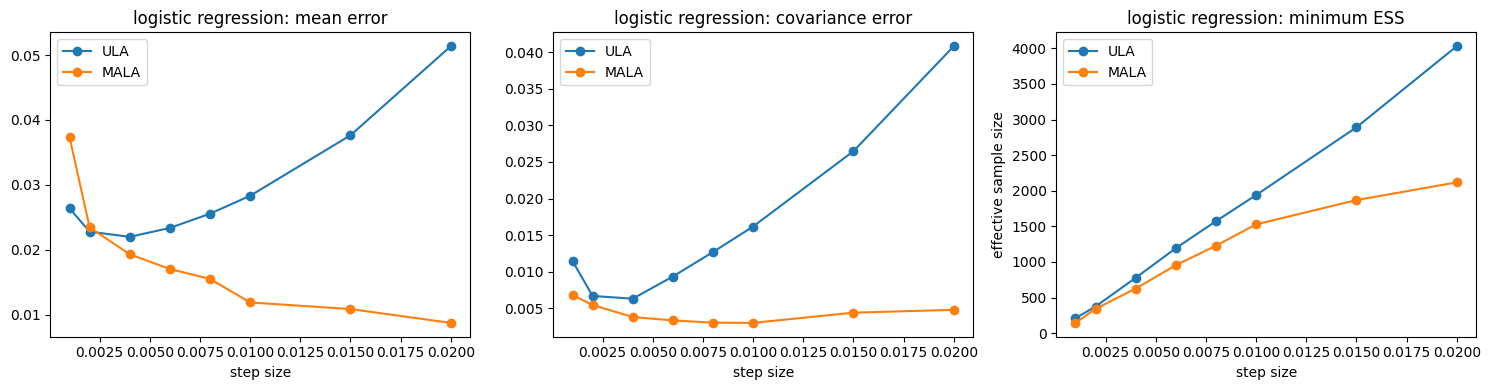

In [66]:
hs = np.array([r["h"] for r in log_rows])

ula_mean = np.array([r["ula_mean"] for r in log_rows])
mala_mean = np.array([r["mala_mean"] for r in log_rows])
ula_cov = np.array([r["ula_cov"] for r in log_rows])
mala_cov = np.array([r["mala_cov"] for r in log_rows])
ula_ess = np.array([r["ula_ess"] for r in log_rows])
mala_ess = np.array([r["mala_ess"] for r in log_rows])

fig, ax = plt.subplots(1, 3, figsize=(15, 4))

ax[0].plot(hs, ula_mean, marker="o", label="ULA")
ax[0].plot(hs, mala_mean, marker="o", label="MALA")
ax[0].set_title("logistic regression: mean error")
ax[0].set_xlabel("step size")
ax[0].legend()

ax[1].plot(hs, ula_cov, marker="o", label="ULA")
ax[1].plot(hs, mala_cov, marker="o", label="MALA")
ax[1].set_title("logistic regression: covariance error")
ax[1].set_xlabel("step size")
ax[1].legend()

ax[2].plot(hs, ula_ess, marker="o", label="ULA")
ax[2].plot(hs, mala_ess, marker="o", label="MALA")
ax[2].set_title("logistic regression: minimum ESS")
ax[2].set_xlabel("step size")
ax[2].set_ylabel("effective sample size")
ax[2].legend()

plt.tight_layout()
plt.show()

ULA can show higher ESS at larger step sizes, but if its mean or covariance error grows at the same time then it is just moving quickly around the wrong approximation. MALA can have lower ESS because it rejects some proposals, but the Metropolis correction usually keeps it closer to the reference posterior. This is exactly why ESS has to be read alongside the error metrics rather than on its own.

TLDR: ULA requires small step sizes to be effective. MALA is more robust.

# Kinetic Langevin comparison

The Langevin methods above are overdamped: the chain only has a position. Kinetic Langevin adds a velocity variable, so the sampler has some momentum as it moves through the posterior.

A simple version is

```text
d theta = v dt
d v = grad log pi(theta) dt - gamma v dt + sqrt(2 gamma) dW.
```

Here `gamma` is a friction parameter. If friction is too high, momentum dies quickly; if it is too low, the sampler can overshoot. The implementation below is deliberately the simple unadjusted Euler version, so it should be compared with ULA as another approximate method rather than as an exact Metropolis-corrected sampler.

In [67]:
def kinetic_langevin(grad_log_prob, x0, step_size, n_samples, gamma=2.0, rng=None):
    """Simple unadjusted kinetic Langevin sampler.

    We keep both a position x and velocity v, but only return the x samples.
    This is an Euler discretisation, so like ULA it can have finite-step bias.
    """
    rng = rng or np.random.default_rng()
    x = np.asarray(x0, dtype=float).copy()
    d = x.shape[0]
    v = rng.standard_normal(d)
    samples = np.empty((n_samples, d))

    noise_scale = np.sqrt(2 * gamma * step_size)

    for k in range(n_samples):
        v = v + step_size * (grad_log_prob(x) - gamma * v) + noise_scale * rng.standard_normal(d)
        x = x + step_size * v
        samples[k] = x

    return samples

## Kinetic Langevin on the correlated Gaussian

NEW: added ESS and commented on its importance.

First I test kinetic Langevin on the same 2D Gaussian target used at the start of the notebook.

The table and plots compare ULA, MALA and kinetic Langevin using the same three diagnostics as before: mean error, covariance error and minimum ESS.

ESS matters especially here: the kinetic sampler's lag-1 autocorrelation is essentially always 1, because the position update `x <- x + h v` moves the state by only a small momentum step each iteration, so consecutive samples are almost identical. Lag-1 autocorrelation therefore cannot distinguish the samplers at all, whereas ESS -- which integrates the whole autocorrelation curve -- can.

      h |  ULA cov  MALA cov  KIN cov |  ULA ESS  MALA ESS  KIN ESS  MALA acc
----------------------------------------------------------------------------------------
  0.005 |    0.421     0.203    0.789 |     24.3      24.5     14.9     0.997
  0.010 |    0.218     0.054    0.410 |     34.6      35.8     21.3     0.992
  0.020 |    0.156     0.073    0.238 |     58.4      53.9     31.7     0.980
  0.050 |    0.047     0.069    0.158 |    183.3      97.7     69.4     0.918
  0.100 |    0.125     0.078    0.038 |    340.7     137.8    176.8     0.780
  0.150 |    0.317     0.081    0.032 |    523.3     244.8    251.1     0.627
  0.180 |    0.899     0.081    0.045 |    763.3     171.3    290.8     0.545


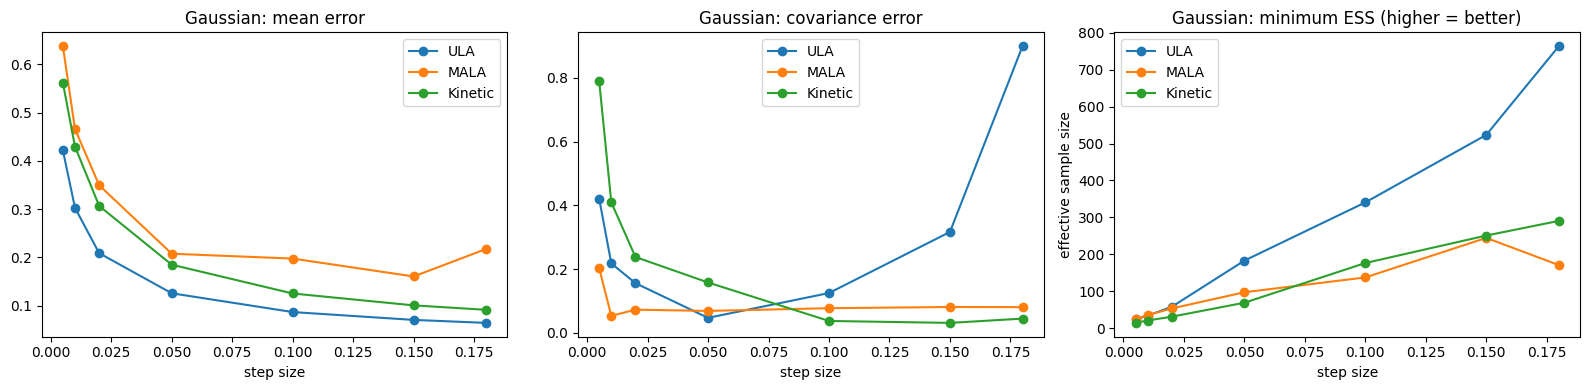

In [68]:
Sigma = np.array([[1.0, 0.9], [0.9, 1.0]])
Sigma_inv = np.linalg.inv(Sigma)

def gauss_log_prob(x):
    return -0.5 * x @ Sigma_inv @ x

def gauss_grad_log_prob(x):
    return -Sigma_inv @ x

true_mean = np.zeros(2)
true_cov = Sigma
step_grid = [0.005, 0.01, 0.02, 0.05, 0.10, 0.15, 0.18]
n_samples_cmp = 12_000
burn_cmp = 2_000
gamma = 2.0
kin_gauss_rows = []

for h in step_grid:
    us = ula(gauss_grad_log_prob, np.zeros(2), h, n_samples_cmp,
             rng=np.random.default_rng(0))[burn_cmp:]
    u_err = gaussian_errors(us, true_mean, true_cov)
    u_ess = min_coordinate_ess(us)

    ms, m_acc = mala(gauss_log_prob, gauss_grad_log_prob, np.zeros(2), h, n_samples_cmp,
                     rng=np.random.default_rng(0))
    ms = ms[burn_cmp:]
    m_err = gaussian_errors(ms, true_mean, true_cov)
    m_ess = min_coordinate_ess(ms)

    ks = kinetic_langevin(gauss_grad_log_prob, np.zeros(2), h, n_samples_cmp,
                          gamma=gamma, rng=np.random.default_rng(0))[burn_cmp:]
    k_err = gaussian_errors(ks, true_mean, true_cov)
    k_ess = min_coordinate_ess(ks)

    kin_gauss_rows.append(dict(
        h=h,
        ula_mean=u_err["mean_error"], ula_cov=u_err["cov_error"], ula_ess=u_ess,
        mala_mean=m_err["mean_error"], mala_cov=m_err["cov_error"], mala_ess=m_ess, mala_acc=m_acc,
        kin_mean=k_err["mean_error"], kin_cov=k_err["cov_error"], kin_ess=k_ess,
    ))

print(f"{'h':>7} | {'ULA cov':>8} {'MALA cov':>9} {'KIN cov':>8} | {'ULA ESS':>8} {'MALA ESS':>9} {'KIN ESS':>8} {'MALA acc':>9}")
print("-" * 88)
for r in kin_gauss_rows:
    print(f"{r['h']:7.3f} | {r['ula_cov']:8.3f} {r['mala_cov']:9.3f} {r['kin_cov']:8.3f} | "
          f"{r['ula_ess']:8.1f} {r['mala_ess']:9.1f} {r['kin_ess']:8.1f} {r['mala_acc']:9.3f}")


hs = np.array([r["h"] for r in kin_gauss_rows])
fig, ax = plt.subplots(1, 3, figsize=(16, 4))

ax[0].plot(hs, [r["ula_mean"] for r in kin_gauss_rows], marker="o", label="ULA")
ax[0].plot(hs, [r["mala_mean"] for r in kin_gauss_rows], marker="o", label="MALA")
ax[0].plot(hs, [r["kin_mean"] for r in kin_gauss_rows], marker="o", label="Kinetic")
ax[0].set_title("Gaussian: mean error")
ax[0].set_xlabel("step size")
ax[0].legend()

ax[1].plot(hs, [r["ula_cov"] for r in kin_gauss_rows], marker="o", label="ULA")
ax[1].plot(hs, [r["mala_cov"] for r in kin_gauss_rows], marker="o", label="MALA")
ax[1].plot(hs, [r["kin_cov"] for r in kin_gauss_rows], marker="o", label="Kinetic")
ax[1].set_title("Gaussian: covariance error")
ax[1].set_xlabel("step size")
ax[1].legend()

ax[2].plot(hs, [r["ula_ess"] for r in kin_gauss_rows], marker="o", label="ULA")
ax[2].plot(hs, [r["mala_ess"] for r in kin_gauss_rows], marker="o", label="MALA")
ax[2].plot(hs, [r["kin_ess"] for r in kin_gauss_rows], marker="o", label="Kinetic")
ax[2].set_title("Gaussian: minimum ESS (higher = better)")
ax[2].set_xlabel("step size")
ax[2].set_ylabel("effective sample size")
ax[2].legend()

plt.tight_layout()
plt.show()

## Kinetic Langevin on Bayesian linear regression

       h |  ULA cov  MALA cov  KIN cov |  ULA ESS  MALA ESS  KIN ESS  MALA acc
------------------------------------------------------------------------------------------
  0.0005 |    0.001     0.001    0.006 |    616.1     617.8     50.4     0.981
  0.0010 |    0.001     0.001    0.003 |   1307.9    1210.1     99.2     0.948
  0.0020 |    0.003     0.000    0.003 |   3065.7    2839.5    198.3     0.855
  0.0030 |    0.005     0.000    0.003 |   5104.1    4185.1    300.7     0.732
  0.0050 |    0.011     0.000    0.002 |  11303.3    4283.4    502.1     0.473
  0.0070 |    0.032     0.001    0.002 |  16000.0    2521.9    683.1     0.261


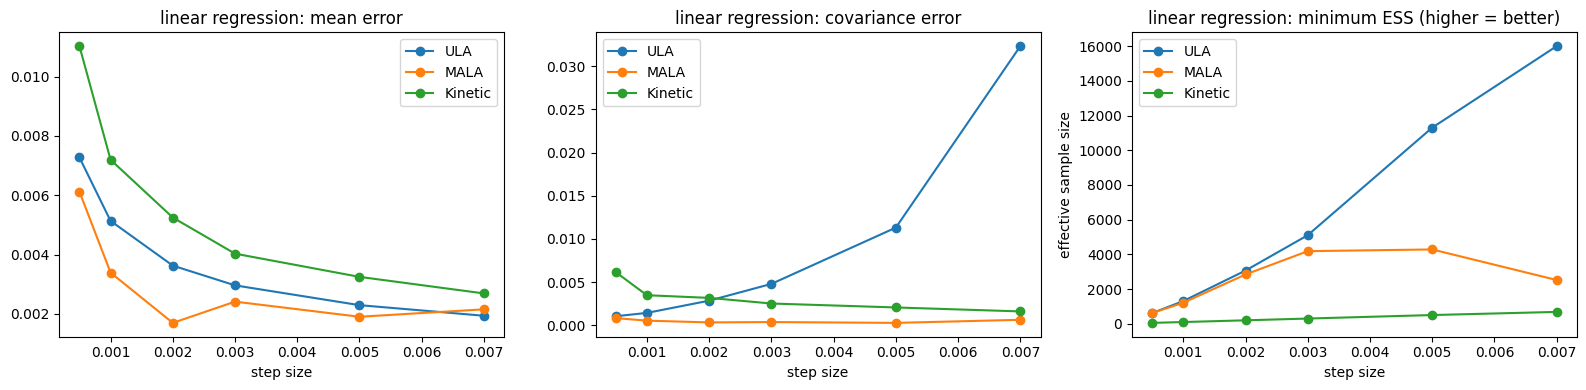

In [69]:
lin_log_prob, lin_grad, post_mean, post_cov = make_linear_regression()
d = post_mean.shape[0]

step_grid = [0.0005, 0.001, 0.002, 0.003, 0.005, 0.007]
n_samples_cmp, burn_cmp = 20_000, 4_000
gamma = 2.0
kin_lin_rows = []

for h in step_grid:
    us = ula(lin_grad, np.zeros(d), h, n_samples_cmp,
             rng=np.random.default_rng(0))[burn_cmp:]
    u_err = gaussian_errors(us, post_mean, post_cov)
    u_ess = min_coordinate_ess(us)

    ms, m_acc = mala(lin_log_prob, lin_grad, np.zeros(d), h, n_samples_cmp,
                     rng=np.random.default_rng(0))
    ms = ms[burn_cmp:]
    m_err = gaussian_errors(ms, post_mean, post_cov)
    m_ess = min_coordinate_ess(ms)

    ks = kinetic_langevin(lin_grad, np.zeros(d), h, n_samples_cmp,
                          gamma=gamma, rng=np.random.default_rng(0))[burn_cmp:]
    k_err = gaussian_errors(ks, post_mean, post_cov)
    k_ess = min_coordinate_ess(ks)

    kin_lin_rows.append(dict(
        h=h,
        ula_mean=u_err["mean_error"], ula_cov=u_err["cov_error"], ula_ess=u_ess,
        mala_mean=m_err["mean_error"], mala_cov=m_err["cov_error"], mala_ess=m_ess, mala_acc=m_acc,
        kin_mean=k_err["mean_error"], kin_cov=k_err["cov_error"], kin_ess=k_ess,
    ))

print(f"{'h':>8} | {'ULA cov':>8} {'MALA cov':>9} {'KIN cov':>8} | {'ULA ESS':>8} {'MALA ESS':>9} {'KIN ESS':>8} {'MALA acc':>9}")
print("-" * 90)
for r in kin_lin_rows:
    print(f"{r['h']:8.4f} | {r['ula_cov']:8.3f} {r['mala_cov']:9.3f} {r['kin_cov']:8.3f} | "
          f"{r['ula_ess']:8.1f} {r['mala_ess']:9.1f} {r['kin_ess']:8.1f} {r['mala_acc']:9.3f}")


hs = np.array([r["h"] for r in kin_lin_rows])
fig, ax = plt.subplots(1, 3, figsize=(16, 4))

ax[0].plot(hs, [r["ula_mean"] for r in kin_lin_rows], marker="o", label="ULA")
ax[0].plot(hs, [r["mala_mean"] for r in kin_lin_rows], marker="o", label="MALA")
ax[0].plot(hs, [r["kin_mean"] for r in kin_lin_rows], marker="o", label="Kinetic")
ax[0].set_title("linear regression: mean error")
ax[0].set_xlabel("step size")
ax[0].legend()

ax[1].plot(hs, [r["ula_cov"] for r in kin_lin_rows], marker="o", label="ULA")
ax[1].plot(hs, [r["mala_cov"] for r in kin_lin_rows], marker="o", label="MALA")
ax[1].plot(hs, [r["kin_cov"] for r in kin_lin_rows], marker="o", label="Kinetic")
ax[1].set_title("linear regression: covariance error")
ax[1].set_xlabel("step size")
ax[1].legend()

ax[2].plot(hs, [r["ula_ess"] for r in kin_lin_rows], marker="o", label="ULA")
ax[2].plot(hs, [r["mala_ess"] for r in kin_lin_rows], marker="o", label="MALA")
ax[2].plot(hs, [r["kin_ess"] for r in kin_lin_rows], marker="o", label="Kinetic")
ax[2].set_title("linear regression: minimum ESS (higher = better)")
ax[2].set_xlabel("step size")
ax[2].set_ylabel("effective sample size")
ax[2].legend()

plt.tight_layout()
plt.show()

NEW: Lag-1 autocorrelation turned out to be the wrong diagnostic for kinetic Langevin: because the position update is `x <- x + h v`, consecutive samples differ only by a small momentum step, so the lag-1 autocorrelation sits at ~1 regardless of how well the chain actually mixes. Throughout the comparisons above we therefore report **effective sample size (ESS)** instead. ESS is built from the integrated autocorrelation time (the whole autocorrelation curve, not a single lag), so it summarises mixing on a scale that is directly comparable across all three samplers.

Remaining items on the roadmap:

* **ESS instead of autocorrelation (done)** -- used as the mixing diagnostic everywhere above.
* Consider the number of gradient evaluations, as these are the expensive operation (below).
* Compare the algorithms on their ability to estimate functionals of the target/posterior -- a standard way of judging effectiveness (below).
* Study step-size variation, as the chain can bounce out and fail to converge to a distribution (Dalalyan gives an optimal step size and asks about log-concavity -- might be interesting to look at higher dimensions for strongly log-concave targets and verify Dalalyan).
* Vary dimensionality.

The mixing helpers (`integrated_autocorr_time`, `effective_sample_size`, `min_coordinate_ess`) are defined near the top of the notebook so the comparisons above can use them. Here we add the remaining diagnostics: functional accuracy and a per-gradient-evaluation efficiency measure. In this notebook, **functional RMSE** is the root mean squared error across posterior summary functionals: coordinate means, coordinate marginal variances, and the quadratic moment `E[||X||^2]`.


In [70]:
def functional_estimates(samples):
    """Posterior summaries estimated from the generated samples."""
    samples = np.asarray(samples, dtype=float)
    out = {}

    # Posterior mean estimates: E[X_j] for each coordinate j.
    for j, value in enumerate(samples.mean(axis=0)):
        out[f"mean_{j}"] = float(value)

    # Posterior marginal variance estimates: Var(X_j) for each coordinate j.
    for j, value in enumerate(samples.var(axis=0, ddof=1)):
        out[f"var_{j}"] = float(value)

    # Quadratic moment estimate: E[||X||^2], combining all coordinates.
    out["quadratic"] = float(np.mean(np.sum(samples**2, axis=1)))
    return out


def gaussian_reference_functionals(mean, cov):
    """Exact values of the same functionals for a Gaussian target."""
    mean = np.asarray(mean, dtype=float)
    cov = np.asarray(cov, dtype=float)
    out = {}

    # Exact means: E[X_j].
    for j, value in enumerate(mean):
        out[f"mean_{j}"] = float(value)

    # Exact marginal variances: diagonal entries of the covariance matrix.
    for j, value in enumerate(np.diag(cov)):
        out[f"var_{j}"] = float(value)

    # Exact quadratic moment: E[||X||^2] = trace(Cov(X)) + ||E[X]||^2.
    out["quadratic"] = float(np.trace(cov) + mean @ mean)
    return out


def functional_error(samples, reference):
    estimates = functional_estimates(samples)
    common = sorted(set(estimates) & set(reference))

    # Root mean squared error over the chosen posterior summaries.
    errors = np.array([estimates[k] - reference[k] for k in common])
    return float(np.sqrt(np.mean(errors**2)))


def sampler_diagnostics(samples, true_mean, true_cov, grad_evals, max_lag=None):
    """Accuracy and efficiency summary for one sampler run."""
    err = gaussian_errors(samples, true_mean, true_cov)
    reference = gaussian_reference_functionals(true_mean, true_cov)
    ess = min_coordinate_ess(samples, max_lag=max_lag)
    return {
        "mean_error": err["mean_error"],
        "cov_error": err["cov_error"],
        "functional_rmse": functional_error(samples, reference),
        "min_ess": ess,
        "grad_evals": int(grad_evals),
        "ess_per_grad": ess / grad_evals,
    }

In [71]:
def kinetic_langevin_exact(grad_log_prob, x0, step_size, n_samples, gamma=2.0, rng=None):
    """First-order kinetic Langevin Monte Carlo with exact OU noise per step.

    Returns
    -------
    samples : ndarray, shape (n_samples, d)
        Position samples.
    grad_evals : int
        Number of gradient evaluations, used as the cost unit.
    """
    rng = rng or np.random.default_rng()
    x = np.asarray(x0, dtype=float).copy()
    d = x.shape[0]
    v = rng.standard_normal(d)
    samples = np.empty((n_samples, d))

    h = float(step_size)
    a = np.exp(-gamma * h)
    psi1 = (1.0 - a) / gamma
    psi2 = (h - psi1) / gamma

    c00 = (1.0 - a**2) / (2.0 * gamma)
    c01 = (1.0 - a)**2 / (2.0 * gamma**2)
    c11 = (h - 2.0 * (1.0 - a) / gamma + (1.0 - a**2) / (2.0 * gamma)) / gamma**2
    noise_cov = 2.0 * gamma * np.array([[c00, c01], [c01, c11]])
    noise_chol = np.linalg.cholesky(noise_cov + 1e-15 * np.eye(2))

    grad_evals = 0
    for k in range(n_samples):
        g = grad_log_prob(x)
        grad_evals += 1
        z = rng.standard_normal((2, d))
        noise = noise_chol @ z
        v_new = a * v + psi1 * g + noise[0]
        x_new = x + psi1 * v + psi2 * g + noise[1]
        v, x = v_new, x_new
        samples[k] = x

    return samples, grad_evals

In [72]:
import numpy as np
import matplotlib.pyplot as plt


def make_correlated_gaussian(d, rho=0.8):
    '''Zero-mean AR(1)-correlated Gaussian target in d dimensions.'''
    idx = np.arange(d)
    cov = rho ** np.abs(idx[:, None] - idx[None, :])
    prec = np.linalg.inv(cov)

    def target_log_prob(x):
        return -0.5 * x @ prec @ x

    def target_grad_log_prob(x):
        return -prec @ x

    return target_log_prob, target_grad_log_prob, np.zeros(d), cov, prec


def empirical_reference_diagnostics(samples, reference_samples, reference_mean, reference_cov,
                                    grad_evals, max_lag=None):
    '''Diagnostics against an empirical reference chain for non-Gaussian targets.'''
    err = gaussian_errors(samples, reference_mean, reference_cov)
    ess = min_coordinate_ess(samples, max_lag=max_lag)
    reference_functionals = functional_estimates(reference_samples)
    return {
        "mean_error": err["mean_error"],
        "cov_error": err["cov_error"],
        "functional_rmse": functional_error(samples, reference_functionals),
        "min_ess": ess,
        "grad_evals": grad_evals,
        "ess_per_grad": ess / grad_evals,
    }


def run_gaussian_sampler(sampler, log_prob, grad_log_prob, x0, h, n_samples, burn,
                         true_mean, true_cov, seed=0, gamma=2.0, max_lag=None):
    '''Run one sampler on a Gaussian target and return standard diagnostics.'''
    rng = np.random.default_rng(seed)

    if sampler == "ULA":
        samples = ula(grad_log_prob, x0, h, n_samples, rng=rng)
        grad_evals = n_samples
        acceptance = np.nan
    elif sampler == "MALA":
        samples, acceptance = mala(log_prob, grad_log_prob, x0, h, n_samples, rng=rng)
        grad_evals = 2 * n_samples
    elif sampler == "KLMC":
        samples, grad_evals = kinetic_langevin_exact(
            grad_log_prob, x0, h, n_samples, gamma=gamma, rng=rng
        )
        acceptance = np.nan
    else:
        raise ValueError(f"unknown sampler: {sampler}")

    diagnostics = sampler_diagnostics(
        samples[burn:], true_mean, true_cov, grad_evals=grad_evals, max_lag=max_lag
    )
    return {"sampler": sampler, "h": h, "acceptance": acceptance, **diagnostics}


def print_experiment_table(rows, title):
    print(title)
    print(f"{'sampler':>7} {'setting':>10} {'h':>9} | {'func RMSE':>10} {'cov err':>9} "
          f"{'min ESS':>9} {'grad evals':>10} {'ESS/grad':>10} {'acc':>7}")
    for r in rows:
        acc = r.get("acceptance", np.nan)
        acc_str = "" if np.isnan(acc) else f"{acc:.3f}"
        print(f"{r['sampler']:>7} {str(r['setting']):>10} {r['h']:9.4g} | "
              f"{r['functional_rmse']:10.4f} {r['cov_error']:9.4f} "
              f"{r['min_ess']:9.1f} {r['grad_evals']:10d} "
              f"{r['ess_per_grad']:10.5f} {acc_str:>7}")


### Investigate computational cost for Bayesian linear regression

Because the Bayesian linear-regression posterior is Gaussian, we can use exact posterior moments as the reference while also scoring functional RMSE and efficiency per gradient evaluation.


Cost-aware Bayesian linear regression
sampler    setting         h |  func RMSE   cov err   min ESS grad evals   ESS/grad     acc
    ULA     linear    0.0005 |     0.0016    0.0009     442.8      12000    0.03690        
   MALA     linear    0.0005 |     0.0030    0.0008     375.0      24000    0.01562   0.980
   KLMC     linear    0.0005 |     0.0227    0.0205      31.3      12000    0.00261        
    ULA     linear     0.001 |     0.0012    0.0012     938.0      12000    0.07817        
   MALA     linear     0.001 |     0.0015    0.0006     878.3      24000    0.03660   0.947
   KLMC     linear     0.001 |     0.0087    0.0071      62.0      12000    0.00517        
    ULA     linear     0.002 |     0.0019    0.0027    2059.3      12000    0.17160        
   MALA     linear     0.002 |     0.0017    0.0004    1771.9      24000    0.07383   0.851
   KLMC     linear     0.002 |     0.0049    0.0058     123.3      12000    0.01028        
    ULA     linear     0.003 |     0.0033 

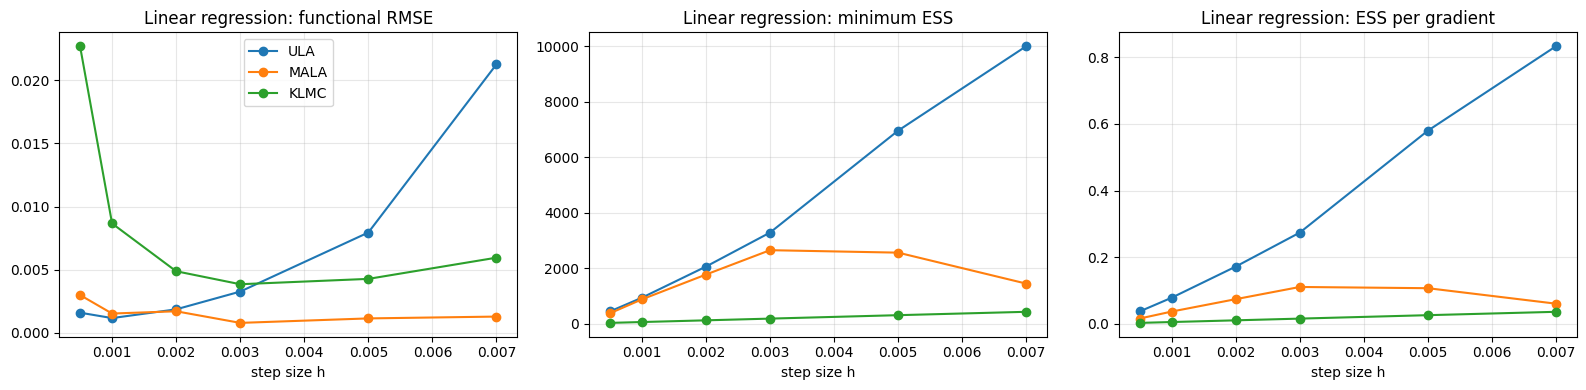

In [ ]:
lin_log_prob_cost, lin_grad_cost, lin_mean_cost, lin_cov_cost = make_linear_regression()
lin_dim_cost = lin_mean_cost.shape[0]
lin_step_grid_cost = [0.0005, 0.001, 0.002, 0.003, 0.005, 0.007]
lin_n_samples_cost = 12_000
lin_burn_cost = 2_000
lin_gamma_cost = 2.0

linear_cost_rows = []
for h_lin in lin_step_grid_cost:
    us_lin = ula(
        lin_grad_cost, np.zeros(lin_dim_cost), h_lin, lin_n_samples_cost,
        rng=np.random.default_rng(300)
    )[lin_burn_cost:]
    u_diag = sampler_diagnostics(
        us_lin, lin_mean_cost, lin_cov_cost, grad_evals=lin_n_samples_cost,
        max_lag=1_000
    )
    linear_cost_rows.append({"sampler": "ULA", "setting": "linear", "h": h_lin, **u_diag})

    ms_lin, m_acc = mala(
        lin_log_prob_cost, lin_grad_cost, np.zeros(lin_dim_cost), h_lin,
        lin_n_samples_cost, rng=np.random.default_rng(300)
    )
    ms_lin = ms_lin[lin_burn_cost:]
    m_diag = sampler_diagnostics(
        ms_lin, lin_mean_cost, lin_cov_cost, grad_evals=2 * lin_n_samples_cost,
        max_lag=1_000
    )
    linear_cost_rows.append({
        "sampler": "MALA", "setting": "linear", "h": h_lin,
        "acceptance": m_acc, **m_diag
    })

    ks_lin, k_grad_evals = kinetic_langevin_exact(
        lin_grad_cost, np.zeros(lin_dim_cost), h_lin, lin_n_samples_cost,
        gamma=lin_gamma_cost, rng=np.random.default_rng(300)
    )
    ks_lin = ks_lin[lin_burn_cost:]
    k_diag = sampler_diagnostics(
        ks_lin, lin_mean_cost, lin_cov_cost, grad_evals=k_grad_evals,
        max_lag=1_000
    )
    linear_cost_rows.append({"sampler": "KLMC", "setting": "linear", "h": h_lin, **k_diag})

print_experiment_table(linear_cost_rows, "Bayesian linear regression")

fig, ax = plt.subplots(1, 3, figsize=(16, 4))
for sampler_lin in ["ULA", "MALA", "KLMC"]:
    rows_s = [r for r in linear_cost_rows if r["sampler"] == sampler_lin]
    hs_lin = [r["h"] for r in rows_s]
    ax[0].plot(hs_lin, [r["functional_rmse"] for r in rows_s], marker="o", label=sampler_lin)
    ax[1].plot(hs_lin, [r["min_ess"] for r in rows_s], marker="o", label=sampler_lin)
    ax[2].plot(hs_lin, [r["ess_per_grad"] for r in rows_s], marker="o", label=sampler_lin)

ax[0].set_title("Linear regression: functional RMSE")
ax[1].set_title("Linear regression: minimum ESS")
ax[2].set_title("Linear regression: ESS per gradient")
for a in ax:
    a.set_xlabel("step size h")
    a.grid(True, alpha=0.3)
ax[0].legend()
plt.tight_layout()
plt.show()


### Investigating correlated Gaussian

same stuff as before, just different diagnostics.

Note: MALA is charged two gradient evaluations per iteration because the current implementation evaluates the gradient at the current and proposed states inside each Metropolis step. ULA and KLMC use one gradient per iteration.

In [74]:
step_grid = [0.005, 0.01, 0.02, 0.05, 0.10, 0.15]
n_samples_cmp = 10_000
burn_cmp = 2_000
gamma = 2.0

cost_rows = []
for h in step_grid:
    us = ula(gauss_grad_log_prob, np.zeros(2), h, n_samples_cmp,
             rng=np.random.default_rng(100))[burn_cmp:]
    u_diag = sampler_diagnostics(us, true_mean, true_cov, grad_evals=n_samples_cmp)
    cost_rows.append({"sampler": "ULA", "h": h, **u_diag})

    ms, m_acc = mala(gauss_log_prob, gauss_grad_log_prob, np.zeros(2), h, n_samples_cmp,
                     rng=np.random.default_rng(100))
    ms = ms[burn_cmp:]
    m_diag = sampler_diagnostics(ms, true_mean, true_cov, grad_evals=2 * n_samples_cmp)
    cost_rows.append({"sampler": "MALA", "h": h, "acceptance": m_acc, **m_diag})

    ks, k_grad_evals = kinetic_langevin_exact(gauss_grad_log_prob, np.zeros(2), h, n_samples_cmp,
                                              gamma=gamma, rng=np.random.default_rng(100))
    ks = ks[burn_cmp:]
    k_diag = sampler_diagnostics(ks, true_mean, true_cov, grad_evals=k_grad_evals)
    cost_rows.append({"sampler": "KLMC", "h": h, **k_diag})

print(f"{'sampler':>7} {'h':>7} | {'func RMSE':>10} {'cov err':>9} {'min ESS':>9} {'ESS/grad':>10} {'acc':>7}")
print("-" * 72)
for r in cost_rows:
    acc = r.get("acceptance", np.nan)
    print(f"{r['sampler']:>7} {r['h']:7.3f} | {r['functional_rmse']:10.4f} {r['cov_error']:9.4f} "
          f"{r['min_ess']:9.1f} {r['ess_per_grad']:10.4f} {acc:7.3f}")

sampler       h |  func RMSE   cov err   min ESS   ESS/grad     acc
------------------------------------------------------------------------
    ULA   0.005 |     0.4905    0.3861      17.7     0.0018     nan
   MALA   0.005 |     0.2454    0.1904      10.1     0.0005   0.998
   KLMC   0.005 |     0.6648    0.1019      10.2     0.0010     nan
    ULA   0.010 |     0.3126    0.1709      27.3     0.0027     nan
   MALA   0.010 |     0.1482    0.0606      16.9     0.0008   0.993
   KLMC   0.010 |     0.4957    0.3934      13.6     0.0014     nan
    ULA   0.020 |     0.2153    0.0152      47.7     0.0048     nan
   MALA   0.020 |     0.0975    0.0629      32.2     0.0016   0.979
   KLMC   0.020 |     0.3182    0.2787      19.7     0.0020     nan
    ULA   0.050 |     0.1714    0.1468     131.8     0.0132     nan
   MALA   0.050 |     0.0553    0.0228     108.5     0.0054   0.919
   KLMC   0.050 |     0.1845    0.1358      40.1     0.0040     nan
    ULA   0.100 |     0.1760    0.1893     

### Interpreting the diagnostics

**Functional RMSE:** lower is better.  
This measures how accurately the sampler estimates posterior summaries such as means, variances and \(E[\|X\|^2]\). A low value means the samples are close to the target for the quantities we care about.

**Minimum coordinate ESS:** higher is better.  
ESS estimates how many independent samples the correlated chain is worth. Taking the minimum across coordinates gives a conservative measure of the worst-mixing direction (coordinate/component of the chain that explores the target distribution slowest).

**ESS per gradient evaluation:** higher is better.  
Gradient evaluations are the main computational cost, so this measures sampling efficiency per unit of expensive work.

Overall, a good sampler should have low functional RMSE and high ESS per gradient evaluation. High ESS alone is not enough, since a biased sampler may move quickly but estimate the wrong target.

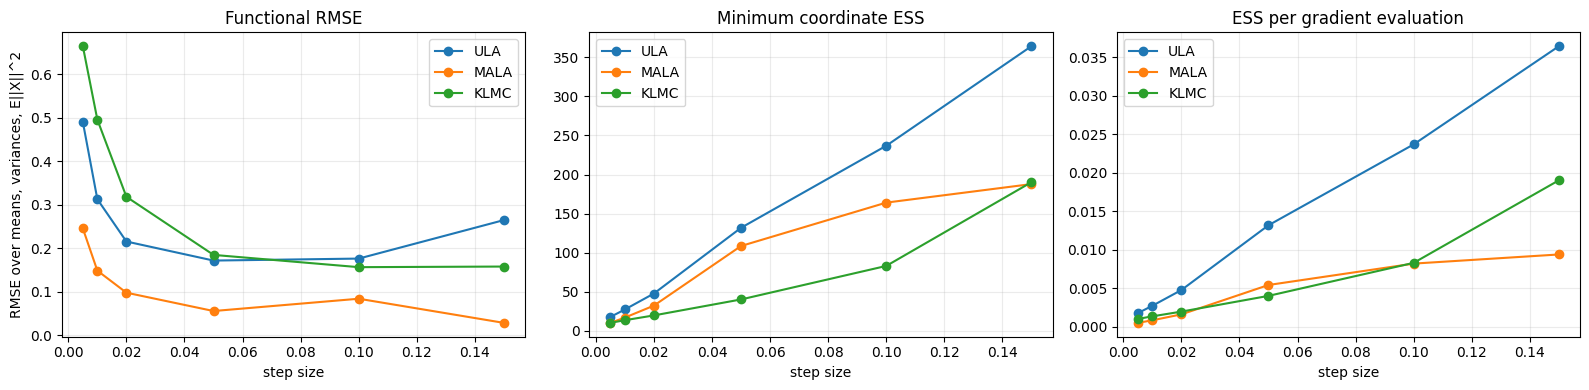

In [75]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4))
samplers = ["ULA", "MALA", "KLMC"]

for sampler in samplers:
    rows_s = [r for r in cost_rows if r["sampler"] == sampler]
    hs = np.array([r["h"] for r in rows_s])
    ax[0].plot(hs, [r["functional_rmse"] for r in rows_s], marker="o", label=sampler)
    ax[1].plot(hs, [r["min_ess"] for r in rows_s], marker="o", label=sampler)
    ax[2].plot(hs, [r["ess_per_grad"] for r in rows_s], marker="o", label=sampler)

ax[0].set_title("Functional RMSE")
ax[0].set_xlabel("step size")
ax[0].set_ylabel("RMSE over means, variances, E||X||^2")

ax[1].set_title("Minimum coordinate ESS")
ax[1].set_xlabel("step size")

ax[2].set_title("ESS per gradient evaluation")
ax[2].set_xlabel("step size")

for a in ax:
    a.legend()
    a.grid(alpha=0.25)

plt.tight_layout()
plt.show()

### Bayesian logistic regression


Cost-aware Bayesian logistic regression
sampler    setting         h |  func RMSE   cov err   min ESS grad evals   ESS/grad     acc
    ULA   logistic     0.001 |     0.0055    0.0042     154.0      30000    0.00513        
   MALA   logistic     0.001 |     0.0108    0.0081     170.6      60000    0.00284   0.994
   KLMC   logistic     0.001 |     0.1067    0.0179      46.5      30000    0.00155        
    ULA   logistic     0.002 |     0.0056    0.0036     323.3      30000    0.01078        
   MALA   logistic     0.002 |     0.0029    0.0050     297.7      60000    0.00496   0.985
   KLMC   logistic     0.002 |     0.0795    0.0216     100.2      30000    0.00334        
    ULA   logistic     0.004 |     0.0143    0.0049     620.3      30000    0.02068        
   MALA   logistic     0.004 |     0.0028    0.0039     580.5      60000    0.00967   0.959
   KLMC   logistic     0.004 |     0.0666    0.0193     188.9      30000    0.00630        
    ULA   logistic     0.006 |     0.022

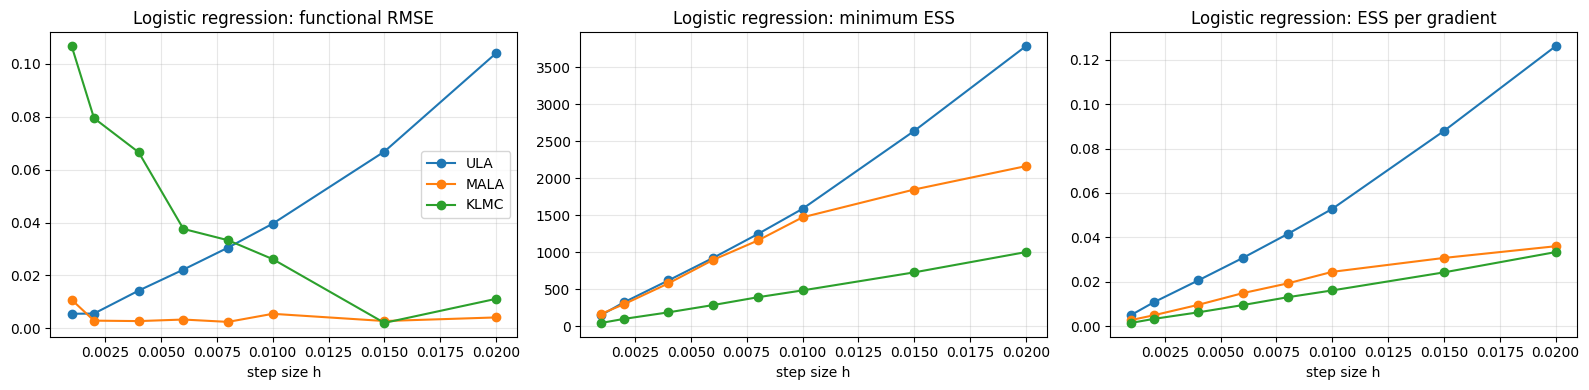

In [76]:
log_cost_step_grid = [0.001, 0.002, 0.004, 0.006, 0.008, 0.010, 0.015, 0.020]
log_cost_n_samples = 30_000
log_cost_burn = 5_000
log_cost_gamma = 2.0

logistic_cost_rows = []
for h_log in log_cost_step_grid:
    us_log = ula(
        grad, beta_map, h_log, log_cost_n_samples,
        rng=np.random.default_rng(700)
    )[log_cost_burn:]
    u_diag = empirical_reference_diagnostics(
        us_log, ref, ref_mean, ref_cov,
        grad_evals=log_cost_n_samples, max_lag=1_000
    )
    logistic_cost_rows.append({'sampler': 'ULA', 'setting': 'logistic', 'h': h_log, **u_diag})

    ms_log, m_acc = mala(
        log_prob, grad, beta_map, h_log, log_cost_n_samples,
        rng=np.random.default_rng(700)
    )
    ms_log = ms_log[log_cost_burn:]
    m_diag = empirical_reference_diagnostics(
        ms_log, ref, ref_mean, ref_cov,
        grad_evals=2 * log_cost_n_samples, max_lag=1_000
    )
    logistic_cost_rows.append({
        'sampler': 'MALA', 'setting': 'logistic', 'h': h_log,
        'acceptance': m_acc, **m_diag
    })

    ks_log, k_grad_evals = kinetic_langevin_exact(
        grad, beta_map, h_log, log_cost_n_samples,
        gamma=log_cost_gamma, rng=np.random.default_rng(700)
    )
    ks_log = ks_log[log_cost_burn:]
    k_diag = empirical_reference_diagnostics(
        ks_log, ref, ref_mean, ref_cov,
        grad_evals=k_grad_evals, max_lag=1_000
    )
    logistic_cost_rows.append({'sampler': 'KLMC', 'setting': 'logistic', 'h': h_log, **k_diag})

print_experiment_table(logistic_cost_rows, 'Cost-aware Bayesian logistic regression')

fig, ax = plt.subplots(1, 3, figsize=(16, 4))
for sampler_log in ['ULA', 'MALA', 'KLMC']:
    rows_s = [r for r in logistic_cost_rows if r['sampler'] == sampler_log]
    hs_log = [r['h'] for r in rows_s]
    ax[0].plot(hs_log, [r['functional_rmse'] for r in rows_s], marker='o', label=sampler_log)
    ax[1].plot(hs_log, [r['min_ess'] for r in rows_s], marker='o', label=sampler_log)
    ax[2].plot(hs_log, [r['ess_per_grad'] for r in rows_s], marker='o', label=sampler_log)

ax[0].set_title('Logistic regression: functional RMSE')
ax[1].set_title('Logistic regression: minimum ESS')
ax[2].set_title('Logistic regression: ESS per gradient')
for a in ax:
    a.set_xlabel('step size h')
    a.grid(True, alpha=0.3)
ax[0].legend()
plt.tight_layout()
plt.show()


## Dimensionality and some more computational cost experiments

The cells below add the remaining scaling experiments: dimensionality scaling, precision scaling, and the KLMC friction sweep.


### Dimensionality scaling

This experiment varies the dimension of a correlated Gaussian target while keeping the target family fixed. The comparison records both accuracy and cost, so the dimension effect is not reduced to wall-clock time alone.


Dimensionality scaling
sampler    setting         h |  func RMSE   cov err   min ESS grad evals   ESS/grad     acc
    ULA        d=2      0.09 |     0.1153    0.1568     196.6      12000    0.01639        
   MALA        d=2      0.15 |     0.0227    0.0110     362.2      24000    0.01509   0.857
   KLMC        d=2      0.12 |     0.0142    0.0525     108.1      12000    0.00901        
    ULA        d=5   0.05496 |     0.2354    0.5626      39.3      12000    0.00327        
   MALA        d=5    0.0916 |     0.2094    0.4826      57.1      24000    0.00238   0.809
   KLMC        d=5   0.07328 |     0.1302    0.4433      55.0      12000    0.00458        
    ULA       d=10   0.05121 |     0.2745    1.3977      86.0      12000    0.00717        
   MALA       d=10   0.08535 |     0.1015    0.6320     102.3      24000    0.00426   0.715
   KLMC       d=10   0.06828 |     0.2455    0.4669      40.1      12000    0.00334        
    ULA       d=20    0.0503 |     0.1658    0.9663      

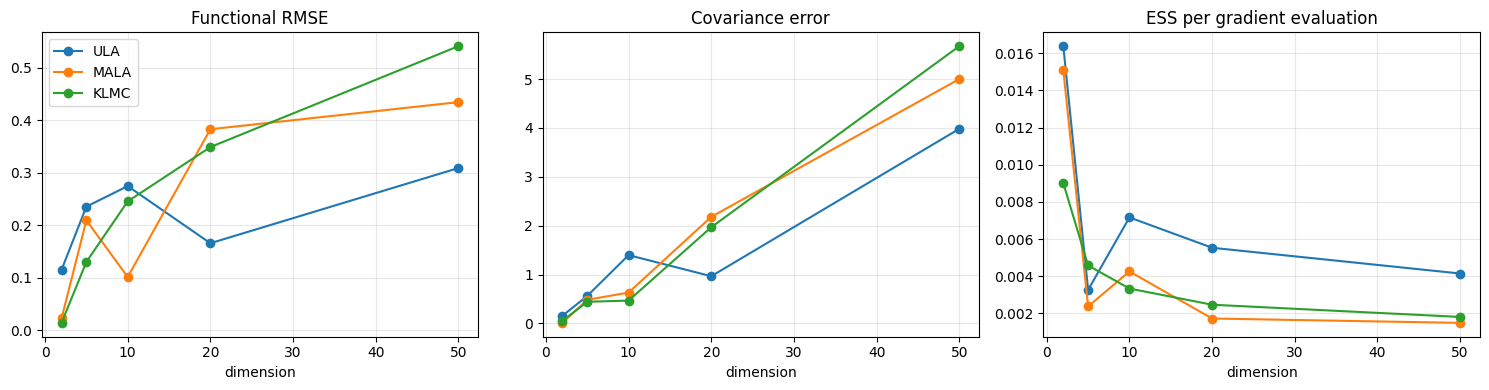

In [77]:
dim_grid = [2, 5, 10, 20, 50]
dim_rho = 0.8
dim_n_samples = 12_000
dim_burn = 2_000
dim_gamma = 2.0
dim_rows = []

for d_dim in dim_grid:
    lp_dim, grad_dim, mean_dim, cov_dim, prec_dim = make_correlated_gaussian(d_dim, rho=dim_rho)
    L_dim = np.linalg.eigvalsh(prec_dim).max()

    # Conservative dimension-aware steps. MALA can tolerate a larger step than ULA here
    # because the Metropolis correction controls bias; KLMC uses the same scale as ULA.
    h_ula_dim = 0.45 / L_dim
    h_mala_dim = 0.75 / L_dim
    h_klmc_dim = 0.60 / L_dim

    for sampler_dim, h_dim in [("ULA", h_ula_dim), ("MALA", h_mala_dim), ("KLMC", h_klmc_dim)]:
        row = run_gaussian_sampler(
            sampler_dim, lp_dim, grad_dim, np.zeros(d_dim), h_dim,
            dim_n_samples, dim_burn, mean_dim, cov_dim,
            seed=100 + d_dim, gamma=dim_gamma, max_lag=1_000
        )
        row["setting"] = f"d={d_dim}"
        row["dimension"] = d_dim
        dim_rows.append(row)

print_experiment_table(dim_rows, "Dimensionality scaling")

fig, ax = plt.subplots(1, 3, figsize=(15, 4))
for sampler_dim in ["ULA", "MALA", "KLMC"]:
    rows_s = [r for r in dim_rows if r["sampler"] == sampler_dim]
    xs = [r["dimension"] for r in rows_s]
    ax[0].plot(xs, [r["functional_rmse"] for r in rows_s], marker="o", label=sampler_dim)
    ax[1].plot(xs, [r["cov_error"] for r in rows_s], marker="o", label=sampler_dim)
    ax[2].plot(xs, [r["ess_per_grad"] for r in rows_s], marker="o", label=sampler_dim)

ax[0].set_title("Functional RMSE")
ax[1].set_title("Covariance error")
ax[2].set_title("ESS per gradient evaluation")
for a in ax:
    a.set_xlabel("dimension")
    a.grid(True, alpha=0.3)
ax[0].legend()
plt.tight_layout()
plt.show()


### Precision scaling

Here the target dimension is fixed and the allowed functional-RMSE tolerance is tightened. For each sampler, the table reports the first finite budget in the grid that reaches each tolerance, if one is reached.


Precision scaling: raw budget grid
sampler    setting         h |  func RMSE   cov err   min ESS grad evals   ESS/grad     acc
    ULA     N=3000   0.05121 |     0.3726    0.9751      12.0       3000    0.00399        
    ULA     N=6000   0.05121 |     0.2269    0.6566      29.4       6000    0.00491        
    ULA    N=12000   0.05121 |     0.1063    0.7662      77.1      12000    0.00643        
    ULA    N=24000   0.05121 |     0.2116    0.6091      77.3      24000    0.00322        
   MALA     N=3000   0.08535 |     1.4760    6.4310      12.4       6000    0.00207   0.725
   MALA     N=6000   0.08535 |     0.3522    1.4098      47.4      12000    0.00395   0.721
   MALA    N=12000   0.08535 |     0.1881    1.0236      94.9      24000    0.00396   0.705
   MALA    N=24000   0.08535 |     0.0437    0.3424     114.1      48000    0.00238   0.721
   KLMC     N=3000   0.06828 |     0.1851    1.1772      20.2       3000    0.00673        
   KLMC     N=6000   0.06828 |     0.2322    

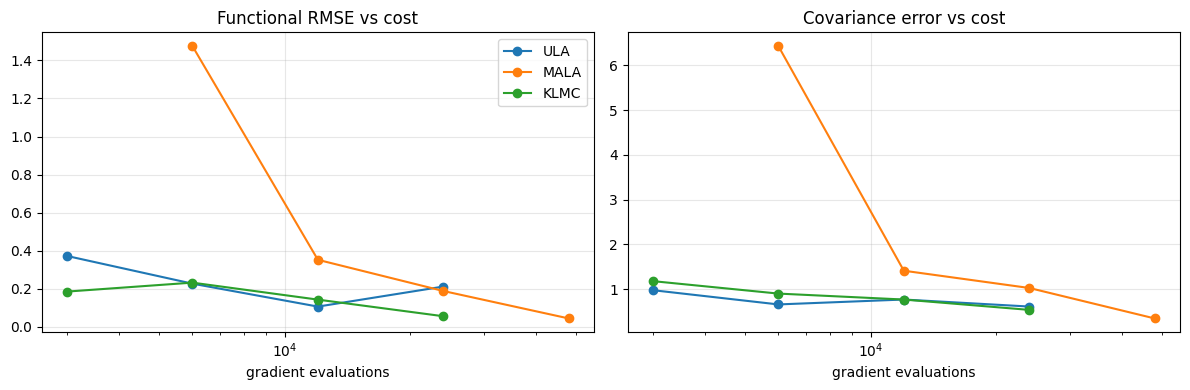

In [78]:
precision_dim = 10
precision_rho = 0.8
precision_budgets = [3_000, 6_000, 12_000, 24_000]
precision_burn_fraction = 0.20
precision_tolerances = [0.35, 0.25, 0.18, 0.125]
precision_gamma = 2.0

lp_prec, grad_prec, mean_prec, cov_prec, prec_prec = make_correlated_gaussian(
    precision_dim, rho=precision_rho
)
L_prec = np.linalg.eigvalsh(prec_prec).max()
precision_steps = {
    "ULA": 0.45 / L_prec,
    "MALA": 0.75 / L_prec,
    "KLMC": 0.60 / L_prec,
}

precision_budget_rows = []
for sampler_prec, h_prec in precision_steps.items():
    for budget in precision_budgets:
        burn = int(precision_burn_fraction * budget)
        row = run_gaussian_sampler(
            sampler_prec, lp_prec, grad_prec, np.zeros(precision_dim), h_prec,
            budget, burn, mean_prec, cov_prec,
            seed=500 + budget + len(sampler_prec), gamma=precision_gamma, max_lag=1_000
        )
        row["setting"] = f"N={budget}"
        row["budget"] = budget
        precision_budget_rows.append(row)

print_experiment_table(precision_budget_rows, "Precision scaling: raw budget grid")

precision_summary_rows = []
for sampler_prec in precision_steps:
    rows_s = [r for r in precision_budget_rows if r["sampler"] == sampler_prec]
    rows_s = sorted(rows_s, key=lambda r: r["budget"])
    for tol in precision_tolerances:
        reached = [r for r in rows_s if r["functional_rmse"] <= tol]
        if reached:
            first = reached[0]
            precision_summary_rows.append({
                "sampler": sampler_prec,
                "tolerance": tol,
                "budget": first["budget"],
                "grad_evals": first["grad_evals"],
                "functional_rmse": first["functional_rmse"],
                "cov_error": first["cov_error"],
            })
        else:
            precision_summary_rows.append({
                "sampler": sampler_prec,
                "tolerance": tol,
                "budget": None,
                "grad_evals": None,
                "functional_rmse": np.nan,
                "cov_error": np.nan,
            })

print("\nPrecision scaling: first budget reaching tolerance")
print(f"{'sampler':>7} {'tol':>8} | {'budget':>8} {'grad evals':>10} {'func RMSE':>10} {'cov err':>9}")
for r in precision_summary_rows:
    budget = "-" if r["budget"] is None else str(r["budget"])
    grad_evals = "-" if r["grad_evals"] is None else str(r["grad_evals"])
    rmse = "-" if np.isnan(r["functional_rmse"]) else f"{r['functional_rmse']:.4f}"
    cov_err = "-" if np.isnan(r["cov_error"]) else f"{r['cov_error']:.4f}"
    print(f"{r['sampler']:>7} {r['tolerance']:8.3f} | {budget:>8} {grad_evals:>10} {rmse:>10} {cov_err:>9}")

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
for sampler_prec in precision_steps:
    rows_s = [r for r in precision_budget_rows if r["sampler"] == sampler_prec]
    xs = [r["grad_evals"] for r in rows_s]
    ax[0].plot(xs, [r["functional_rmse"] for r in rows_s], marker="o", label=sampler_prec)
    ax[1].plot(xs, [r["cov_error"] for r in rows_s], marker="o", label=sampler_prec)

ax[0].set_title("Functional RMSE vs cost")
ax[1].set_title("Covariance error vs cost")
for a in ax:
    a.set_xlabel("gradient evaluations")
    a.set_xscale("log")
    a.grid(True, alpha=0.3)
ax[0].legend()
plt.tight_layout()
plt.show()


### KLMC friction parameter sweep

The friction sweep uses the same correlated Gaussian benchmark as the cost-aware comparison. The target is exact, so changes in the table isolate the effect of the KLMC friction parameter on accuracy and mixing.


KLMC friction parameter sweep
sampler    setting         h |  func RMSE   cov err   min ESS grad evals   ESS/grad     acc
   KLMC gamma=0.25   0.06828 | 77441484764481421312.0000 331195768122763313152.0000    1326.1      16000    0.08288        
   KLMC  gamma=0.5   0.06828 |     0.3529    0.7722     221.9      16000    0.01387        
   KLMC  gamma=1.0   0.06828 |     0.0864    0.4079     146.3      16000    0.00914        
   KLMC  gamma=2.0   0.06828 |     0.1269    0.5315      67.9      16000    0.00424        
   KLMC  gamma=4.0   0.06828 |     0.3070    1.0106      33.1      16000    0.00207        
   KLMC  gamma=8.0   0.06828 |     0.4913    1.7033      22.9      16000    0.00143        


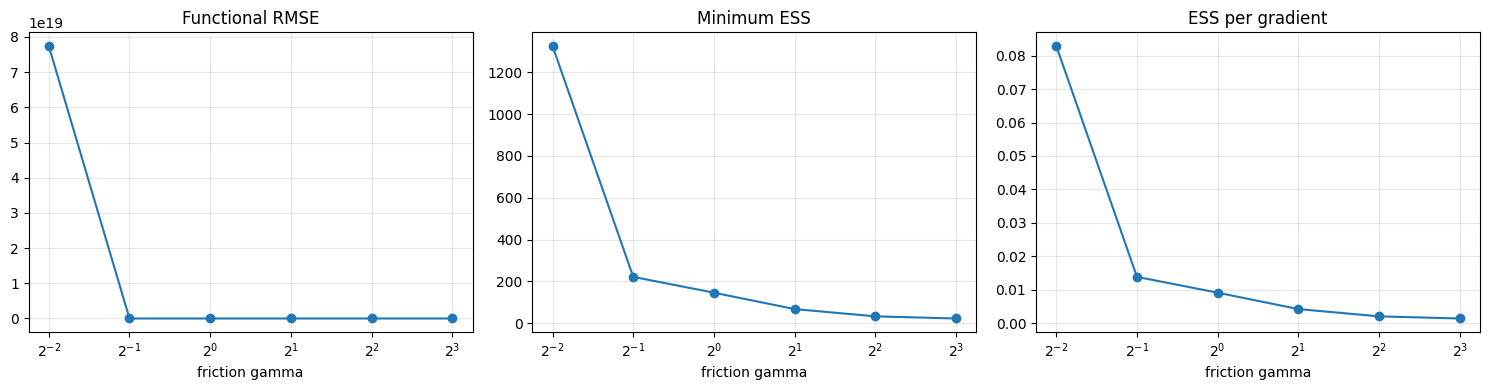

In [79]:
friction_dim = 10
friction_rho = 0.8
friction_gamma_grid = [0.25, 0.5, 1.0, 2.0, 4.0, 8.0]
friction_n_samples = 16_000
friction_burn = 3_000

lp_fric, grad_fric, mean_fric, cov_fric, prec_fric = make_correlated_gaussian(
    friction_dim, rho=friction_rho
)
L_fric = np.linalg.eigvalsh(prec_fric).max()
friction_h = 0.60 / L_fric

friction_rows = []
for gamma_fric in friction_gamma_grid:
    ks_fric, k_grad_evals = kinetic_langevin_exact(
        grad_fric, np.zeros(friction_dim), friction_h, friction_n_samples,
        gamma=gamma_fric, rng=np.random.default_rng(900)
    )
    k_diag = sampler_diagnostics(
        ks_fric[friction_burn:], mean_fric, cov_fric,
        grad_evals=k_grad_evals, max_lag=1_000
    )
    friction_rows.append({
        "sampler": "KLMC",
        "setting": f"gamma={gamma_fric}",
        "gamma": gamma_fric,
        "h": friction_h,
        **k_diag,
    })

print_experiment_table(friction_rows, "KLMC friction parameter sweep")

fig, ax = plt.subplots(1, 3, figsize=(15, 4))
gammas = [r["gamma"] for r in friction_rows]
ax[0].plot(gammas, [r["functional_rmse"] for r in friction_rows], marker="o")
ax[1].plot(gammas, [r["min_ess"] for r in friction_rows], marker="o")
ax[2].plot(gammas, [r["ess_per_grad"] for r in friction_rows], marker="o")
ax[0].set_title("Functional RMSE")
ax[1].set_title("Minimum ESS")
ax[2].set_title("ESS per gradient")
for a in ax:
    a.set_xlabel("friction gamma")
    a.set_xscale("log", base=2)
    a.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
